## MovieLens 1M
Para este proyecto usaremos el DataSet de MovieLens 1M

In [ ]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Download latest version
path = kagglehub.dataset_download("odedgolden/movielens-1m-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'movielens-1m-dataset' dataset.
Path to dataset files: /kaggle/input/movielens-1m-dataset


In [ ]:
print(os.listdir(path))

['users.dat', 'ratings.dat', 'README', 'movies.dat']


Cargamos todos los datos, ya que usaremos las interacciones y las informaciones de peliculas y usuarios

In [ ]:
ratings = pd.read_csv(path + "/ratings.dat", sep="::", engine="python",
                      names=["user_id", "movie_id", "rating", "timestamp"])

movies = pd.read_csv(path + "/movies.dat", sep="::", engine="python",
                     names=["movie_id", "title", "genres"], encoding="latin-1" )

users = pd.read_csv(path + "/users.dat", sep="::", engine="python",
                    names=["user_id", "gender", "age", "occupation", "zip"])

In [ ]:
# Limpiar títulos y extraer año
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

print(movies[['title', 'clean_title', 'year']].head())

                                title                  clean_title  year
0                    Toy Story (1995)                    Toy Story  1995
1                      Jumanji (1995)                      Jumanji  1995
2             Grumpier Old Men (1995)             Grumpier Old Men  1995
3            Waiting to Exhale (1995)            Waiting to Exhale  1995
4  Father of the Bride Part II (1995)  Father of the Bride Part II  1995


### Buscamos cada pelicula en TMDB

uso de IA:  https://claude.ai/share/0b114bc1-f1c6-4093-a5f8-4a2e5f293089

In [ ]:
import requests, time

API_KEY = "936b5bd80b5f710400fbe0084720595a"
BASE = "https://api.themoviedb.org/3"

def search_movie(title, year):
    url = f"{BASE}/search/movie"
    params = {"api_key": API_KEY, "query": title, "year": year}
    r = requests.get(url, params=params).json()
    results = r.get("results", [])
    return results[0] if results else None  #primer resultado

# Aplicar a todo el catálogo
tmdb_results = []
for _, row in movies.iterrows():
    result = search_movie(row['clean_title'], row['year'])
    tmdb_results.append({
        "movie_id": row['movie_id'],   # ← corregido
        "tmdb_id": result['id'] if result else None,
        "found": result is not None
    })
    time.sleep(0.1)

mapping = pd.DataFrame(tmdb_results)
print(f"Cobertura: {mapping['found'].mean():.1%}")

Cobertura: 94.1%


In [ ]:
print("=== MAPPING TMDB ===")
print(mapping.shape)
print(mapping.head(10))

print(f"\n=== COBERTURA ===")
print(f"Total películas:        {len(mapping)}")
print(f"Encontradas en TMDB:    {mapping['found'].sum()} ({mapping['found'].mean():.1%})")
print(f"No encontradas:         {(~mapping['found']).sum()}")

print("\n=== PELÍCULAS NO ENCONTRADAS (muestra) ===")
not_found = mapping[~mapping['found']]['movie_id'].values
movies_not_found = movies[movies['movie_id'].isin(not_found)]
print(movies_not_found[['movie_id','title']].head(15))

print("\n=== MUESTRA DE MATCHES ===")
found = mapping[mapping['found']].head(10)
print(found)

=== MAPPING TMDB ===
(3883, 3)
   movie_id  tmdb_id  found
0         1    862.0   True
1         2   8844.0   True
2         3  15602.0   True
3         4  31357.0   True
4         5  11862.0   True
5         6    949.0   True
6         7  11860.0   True
7         8  45325.0   True
8         9   9091.0   True
9        10    710.0   True

=== COBERTURA ===
Total películas:        3883
Encontradas en TMDB:    3654 (94.1%)
No encontradas:         229

=== PELÍCULAS NO ENCONTRADAS (muestra) ===
     movie_id                                              title
119       121                    Boys of St. Vincent, The (1993)
125       127  Silence of the Palace, The (Saimt el Qusur) (1...
126       128                              Jupiter's Wife (1994)
155       157                              Canadian Bacon (1994)
181       183                                Mute Witness (1994)
227       230                           Dolores Claiborne (1994)
245       248                                  Ho

## Agregamos la sinopsis

In [ ]:
overviews = []

for i, row in mapping.iterrows():
    if row['found'] and pd.notna(row['tmdb_id']):
        try:
            url = f"{BASE}/movie/{int(row['tmdb_id'])}"
            r = requests.get(url, params={"api_key": API_KEY}, timeout=10).json()
            overview = r.get("overview", "")
        except Exception as e:
            overview = ""
    else:
        overview = ""

    overviews.append(overview)

    # Progreso cada 500
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/3883 procesadas...")

    time.sleep(0.07)

# Asignar y guardar
mapping['overview'] = overviews
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)

has_text = mapping['overview'].str.len() > 20
print(f"\nCon sinopsis: {has_text.sum()} ({has_text.mean():.1%})")
print(mapping[has_text][['movie_id','overview']].head(2).to_string())


  500/3883 procesadas...
  1000/3883 procesadas...
  1500/3883 procesadas...
  2000/3883 procesadas...
  2500/3883 procesadas...
  3000/3883 procesadas...
  3500/3883 procesadas...

Con sinopsis: 3651 (94.0%)
   movie_id                                                                                                                                                                                                                                                                                                                                                                                                     overview
0         1                                                                                              Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to pu

In [ ]:
# Ver qué columnas tiene mapping actualmente
print(mapping.columns.tolist())
print(mapping.shape)

['movie_id', 'tmdb_id', 'found', 'overview']
(3883, 4)


In [ ]:
has_text = mapping['overview'].str.len() > 20
print(f"\nCon sinopsis real:   {has_text.sum()} ({has_text.mean():.1%})")
print(f"Sin sinopsis:        {(~has_text).sum()}")
print("\nEjemplos:")
print(mapping[has_text][['movie_id','overview']].head(3).to_string())

# Guardar por si acaso
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)
print("\n✓ Guardado en movielens_tmdb_mapping.csv")


Con sinopsis real:   3651 (94.0%)
Sin sinopsis:        232

Ejemplos:
   movie_id                                                                                                                                                                                                                                                                                                                                                                                                     overview
0         1                                                                                              Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.
1         2  When siblings Judy and Peter discover an enchanted board game that opens the door to a magical wor

## Agregamos los posters

In [ ]:
import os
from PIL import Image
from io import BytesIO

os.makedirs("posters", exist_ok=True)
IMG_BASE = "https://image.tmdb.org/t/p/w342"

def download_poster(tmdb_id, movie_id):
    try:
        url = f"{BASE}/movie/{int(tmdb_id)}"
        r = requests.get(url, params={"api_key": API_KEY}, timeout=10).json()
        path = r.get("poster_path")
        if not path:
            return False
        img_r = requests.get(IMG_BASE + path, timeout=10)
        img = Image.open(BytesIO(img_r.content)).convert("RGB")
        img.save(f"posters/{int(movie_id)}.jpg")
        return True
    except Exception:
        return False

print("Descargando posters... (~15 minutos)")

has_poster = []
for i, row in mapping.iterrows():
    if row['found'] and pd.notna(row['tmdb_id']):
        result = download_poster(row['tmdb_id'], row['movie_id'])
        time.sleep(0.07)
    else:
        result = False

    has_poster.append(result)

    if (i + 1) % 500 == 0:
        print(f"  {i+1}/3883 procesadas...")

mapping['has_poster'] = has_poster
mapping.to_csv("movielens_tmdb_mapping.csv", index=False)

print(f"\nCon poster:   {mapping['has_poster'].sum()} ({mapping['has_poster'].mean():.1%})")
print(f"Sin poster:   {(~mapping['has_poster']).sum()}")
print(f"\n=== COBERTURA FINAL ===")
print(f"Total películas ML1M : {len(mapping)}")
print(f"Encontradas en TMDB  : {mapping['found'].sum()} (94.1%)")
print(f"Con sinopsis         : {(mapping['overview'].str.len() > 20).sum()}")
print(f"Con poster           : {mapping['has_poster'].sum()}")

Descargando posters... (~15 minutos)
  500/3883 procesadas...
  1000/3883 procesadas...
  1500/3883 procesadas...
  2000/3883 procesadas...
  2500/3883 procesadas...
  3000/3883 procesadas...
  3500/3883 procesadas...

Con poster:   3647 (93.9%)
Sin poster:   236

=== COBERTURA FINAL ===
Total películas ML1M : 3883
Encontradas en TMDB  : 3654 (94.1%)
Con sinopsis         : 3651
Con poster           : 3647


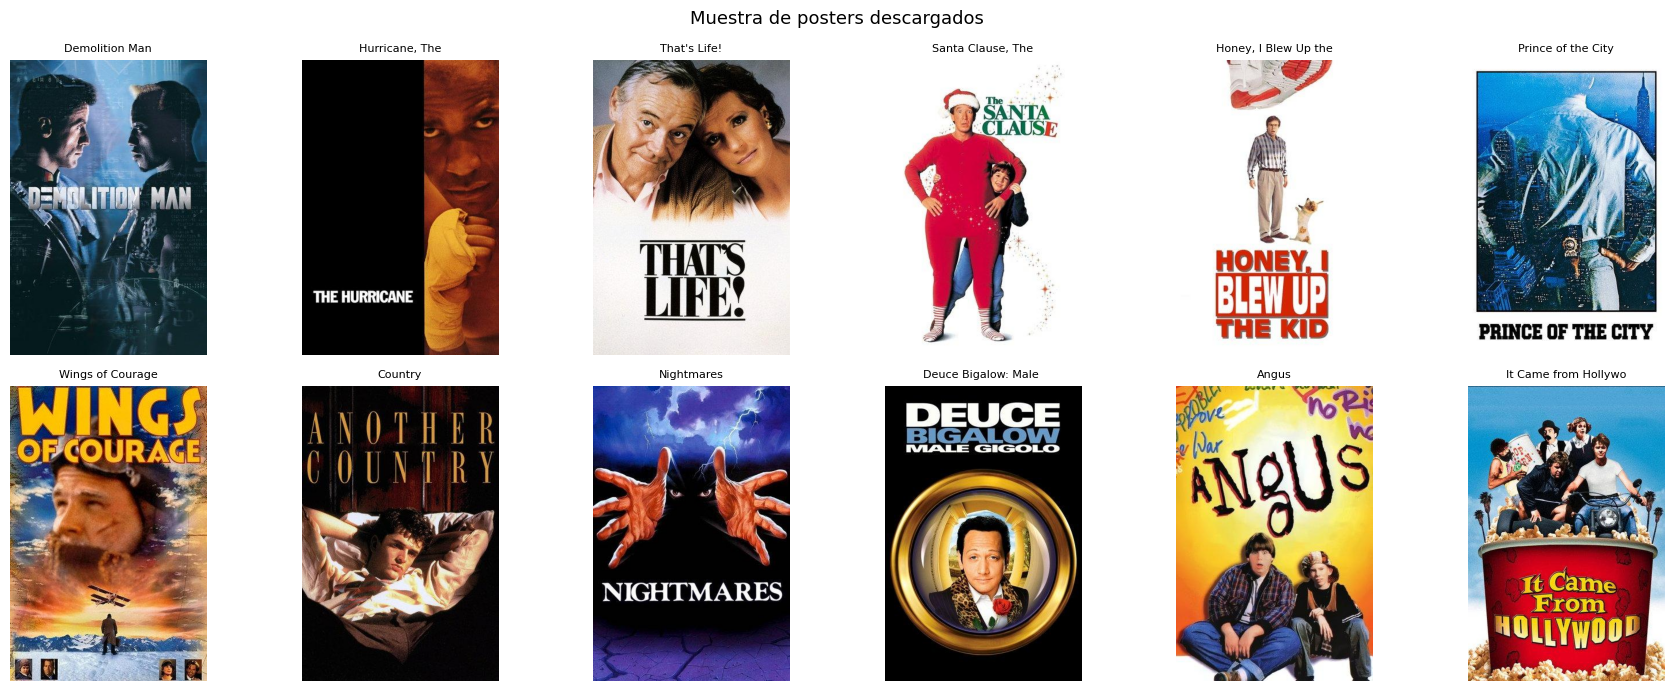

In [ ]:
sample = mapping[mapping['has_poster']].sample(12, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(f"posters/{int(row['movie_id'])}.jpg")
    title = movies[movies['movie_id'] == row['movie_id']]['clean_title'].values[0]
    ax.imshow(img)
    ax.set_title(title[:20], fontsize=8)
    ax.axis('off')

plt.suptitle('Muestra de posters descargados', fontsize=13)
plt.tight_layout()
plt.savefig('sample_posters.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
import os

os.makedirs("embeddings", exist_ok=True)
model_text = SentenceTransformer('all-MiniLM-L6-v2')
texts = mapping['overview'].fillna("").tolist()
text_embeddings = model_text.encode(texts, batch_size=64, show_progress_bar=True)

np.save("embeddings/text_embeddings.npy", text_embeddings)
print(f"Text embeddings shape: {text_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Text embeddings shape: (3883, 384)


In [ ]:
import torch
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image
import numpy as np
import os

# Usar CLIPVisionModel en lugar de CLIPModel
clip_model = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

# Detectar dimensión
test_img = Image.new("RGB", (224, 224))
test_input = clip_processor(images=test_img, return_tensors="pt")
with torch.no_grad():
    test_out = clip_model(**test_input)
    test_emb = test_out.pooler_output  # ← pooler_output es el tensor
EMB_DIM = test_emb.shape[-1]
print(f"Dimensión detectada: {EMB_DIM}")

# Generar embeddings
image_embeddings = np.zeros((len(mapping), EMB_DIM))

for i, row in mapping.iterrows():
    path = f"posters/{int(row['movie_id'])}.jpg"
    if os.path.exists(path):
        try:
            img = Image.open(path).convert("RGB")
            inputs = clip_processor(images=img, return_tensors="pt")
            with torch.no_grad():
                out = clip_model(**inputs)
                emb = out.pooler_output.detach().numpy().flatten()
            image_embeddings[i] = emb
        except Exception:
            pass

    if (i + 1) % 500 == 0:
        print(f"  {i+1}/3883...")

np.save("embeddings/image_embeddings.npy", image_embeddings)
print(f"Image embeddings shape: {image_embeddings.shape}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias          

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Dimensión detectada: 768
  500/3883...
  1000/3883...
  1500/3883...
  2000/3883...
  2500/3883...
  3000/3883...
  3500/3883...
Image embeddings shape: (3883, 768)


In [ ]:
# Cargar embeddings
text_emb = np.load("embeddings/text_embeddings.npy")
img_emb  = np.load("embeddings/image_embeddings.npy")

print(f"Text embeddings: {text_emb.shape}")   # (3883, 384)
print(f"Image embeddings: {img_emb.shape}")   # (3883, 768)

# Crear tabla maestra
mapping = mapping.reset_index(drop=True)
mapping['emb_idx'] = mapping.index

item_table = mapping[['movie_id','tmdb_id','found','overview','has_poster','emb_idx']].merge(
    movies[['movie_id','clean_title','genres','year']], on='movie_id'
)

item_table.to_csv("item_table.csv", index=False)

print(f"\nItem table shape: {item_table.shape}")
print(item_table.head(3))

# Verificar acceso a embeddings
test_id = 1  # Toy Story
idx = item_table[item_table['movie_id'] == test_id]['emb_idx'].values[0]
print(f"\nToy Story → emb_idx: {idx}")
print(f"Text emb shape:  {text_emb[idx].shape}")
print(f"Image emb shape: {img_emb[idx].shape}")
print(f"Text emb (primeros 5 valores): {text_emb[idx][:5]}")

Text embeddings: (3883, 384)
Image embeddings: (3883, 768)

Item table shape: (3883, 9)
   movie_id  tmdb_id  found  \
0         1    862.0   True   
1         2   8844.0   True   
2         3  15602.0   True   

                                            overview  has_poster  emb_idx  \
0  Led by Woody, Andy's toys live happily in his ...        True        0   
1  When siblings Judy and Peter discover an encha...        True        1   
2  A family wedding reignites the ancient feud be...        True        2   

        clean_title                        genres  year  
0         Toy Story   Animation|Children's|Comedy  1995  
1           Jumanji  Adventure|Children's|Fantasy  1995  
2  Grumpier Old Men                Comedy|Romance  1995  

Toy Story → emb_idx: 0
Text emb shape:  (384,)
Image emb shape: (768,)
Text emb (primeros 5 valores): [ 0.06343896  0.00102697  0.09321018 -0.01494169 -0.00640026]


Juntamos toda la información en un solo dataframe

In [ ]:
df = ratings.merge(movies, on="movie_id").merge(users, on="user_id")

print(df.head())

   user_id  movie_id  rating  timestamp  \
0        1      1193       5  978300760   
1        1       661       3  978302109   
2        1       914       3  978301968   
3        1      3408       4  978300275   
4        1      2355       5  978824291   

                                    title                        genres  year  \
0  One Flew Over the Cuckoo's Nest (1975)                         Drama  1975   
1        James and the Giant Peach (1996)  Animation|Children's|Musical  1996   
2                     My Fair Lady (1964)               Musical|Romance  1964   
3                  Erin Brockovich (2000)                         Drama  2000   
4                    Bug's Life, A (1998)   Animation|Children's|Comedy  1998   

                       clean_title gender  age  occupation    zip  
0  One Flew Over the Cuckoo's Nest      F    1          10  48067  
1        James and the Giant Peach      F    1          10  48067  
2                     My Fair Lady      F    1    

Estadisticas generales:

In [ ]:
print("Número de usuarios:", df["user_id"].nunique())
print("Número de películas:", df["movie_id"].nunique())
print("Número de ratings:", len(df))

Número de usuarios: 6040
Número de películas: 3706
Número de ratings: 1000209


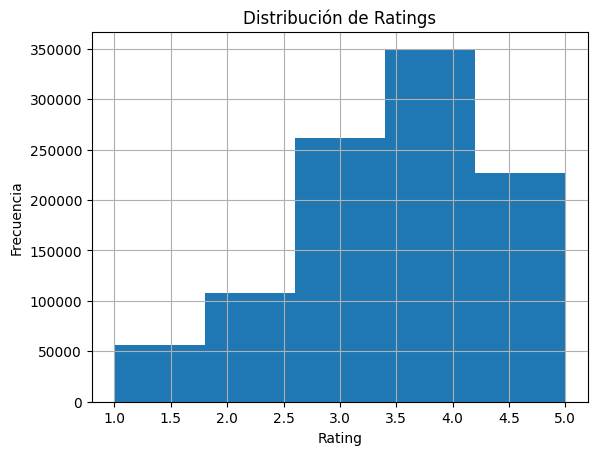

In [ ]:
plt.figure()
df["rating"].hist(bins=5)
plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
print("Promedio de rating:", df["rating"].mean())

Promedio de rating: 3.581564453029317


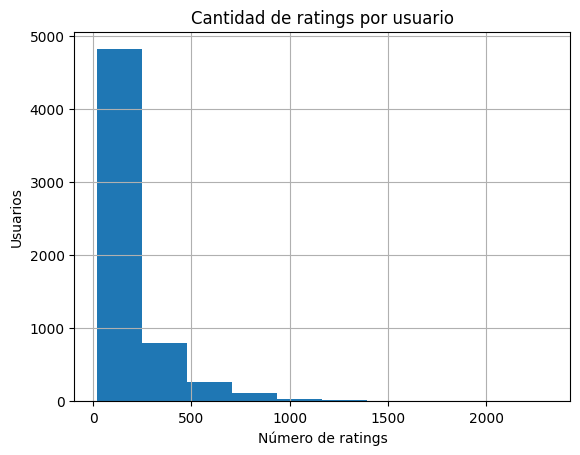

In [ ]:
ratings_per_user = df.groupby("user_id")["rating"].count()

plt.figure()
ratings_per_user.hist()
plt.title("Cantidad de ratings por usuario")
plt.xlabel("Número de ratings")
plt.ylabel("Usuarios")
plt.show()

In [ ]:
mean_ratings = ratings_per_user.mean()
print("Promedio de ratings por película:", mean_ratings)

Promedio de ratings por película: 165.5975165562914


In [ ]:
median_ratings = ratings_per_user.median()
print("Mediana de ratings por película:", median_ratings)

Mediana de ratings por película: 96.0


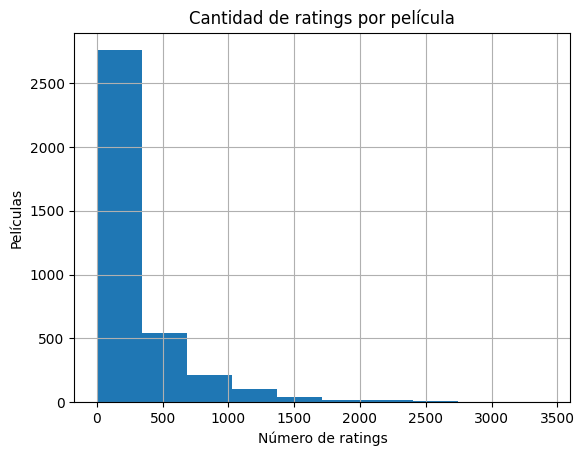

In [ ]:
ratings_per_movie = df.groupby("movie_id")["rating"].count()

plt.figure()
ratings_per_movie.hist()
plt.title("Cantidad de ratings por película")
plt.xlabel("Número de ratings")
plt.ylabel("Películas")
plt.show()

In [ ]:
mean_ratings = ratings_per_movie.mean()
print("Promedio de ratings por película:", mean_ratings)

Promedio de ratings por película: 269.88909875876953


In [ ]:
median_ratings = ratings_per_movie.median()
print("Mediana de ratings por película:", median_ratings)

Mediana de ratings por película: 123.5


In [ ]:
genres = df["genres"].str.split("|")

In [ ]:
from collections import Counter

all_genres = [g for sublist in genres for g in sublist]
genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=["genre", "count"])
genre_df = genre_df.sort_values(by="count", ascending=False)

print(genre_df.head(10))

         genre   count
5       Comedy  356580
0        Drama  354529
6       Action  257457
11    Thriller  189680
9       Sci-Fi  157294
4      Romance  147523
7    Adventure  133953
12       Crime   79541
15      Horror   76386
2   Children's   72186


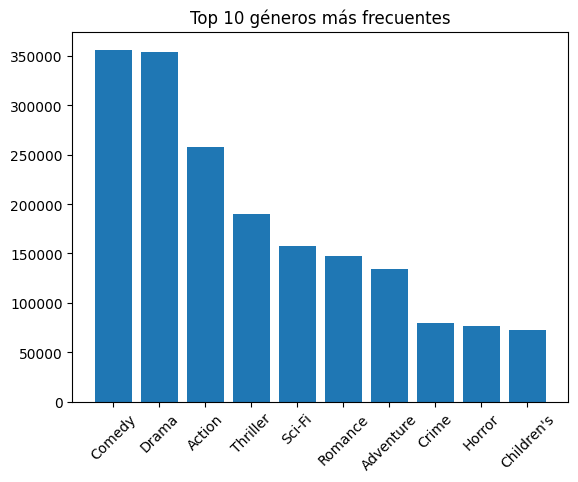

In [ ]:
plt.figure()
plt.bar(genre_df["genre"][:10], genre_df["count"][:10])
plt.xticks(rotation=45)
plt.title("Top 10 géneros más frecuentes")
plt.show()

In [ ]:
print(users["gender"].value_counts())

gender
M    4331
F    1709
Name: count, dtype: int64


In [ ]:
num_users = df["user_id"].nunique()
num_movies = df["movie_id"].nunique()

sparsity = 1 - (len(df) / (num_users * num_movies))

print("Sparsity:", sparsity)

Sparsity: 0.9553163743776871


Implementacion de al menos 3 modelos de referencia

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

Consideramos relevantes de 3 hacia arriba

In [ ]:
test_user_likes = test[test["rating"] >= 3].groupby("user_id")["movie_id"].apply(set)

In [ ]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    if len(recommended_k) == 0:
        return 0

    hits = len(set(recommended_k) & relevant_set)
    return hits / k

In [ ]:
def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    if len(relevant_set) == 0:
        return 0

    hits = len(set(recommended_k) & relevant_set)
    return hits / len(relevant_set)

In [ ]:
def evaluate_model(model_func, users, k=10):
    precisions = []
    recalls = []

    for user in users:
        if user not in test_user_likes:
            continue

        relevant = test_user_likes[user]
        recommended = model_func(user, k)

        precisions.append(precision_at_k(recommended, relevant, k))
        recalls.append(recall_at_k(recommended, relevant, k))

    return np.mean(precisions), np.mean(recalls)

Random

In [ ]:
all_movies = train["movie_id"].unique()

def random_recommender(user_id, k=10):
    return np.random.choice(all_movies, size=k, replace=False)

In [ ]:
prec_r, rec_r = evaluate_model(random_recommender, df["user_id"].unique())

In [ ]:
print("Random -> Precision:", prec_r, "Recall:", rec_r)


Random -> Precision: 0.007292011932383162 Recall: 0.0026660041341291197


Most *popular*

In [ ]:
movie_popularity = train.groupby("movie_id").size().sort_values(ascending=False)
def most_popular_recommender(user_id, k=10):
    return movie_popularity.head(k).index.tolist()

In [ ]:
prec_p, rec_p = evaluate_model(most_popular_recommender, df["user_id"].unique())

In [ ]:
print("Popular -> Precision:", prec_p, "Recall:", rec_p)


Popular -> Precision: 0.08882996353994034 Recall: 0.04893987738464019


Corrección de bug asistida pro IA: https://chatgpt.com/share/69fa06c5-daa4-8333-8ea8-2db98013231e


Modelo 3:

In [ ]:
#train, test = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
!pip install pyreclab --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pyreclab

In [ ]:
train[["user_id", "movie_id", "rating"]].to_csv("data_train", sep="\t", index=False, header=False)

In [ ]:
test[["user_id", "movie_id", "rating"]].to_csv("data_test", sep="\t", index=False, header=False)

In [ ]:
# Definicion de objeto svd
svd = pyreclab.SVD(dataset="data_train",
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Entrenamiento del modelo
svd.train(factors=80, maxiter=50, lr=0.01, lamb=0.1)

In [ ]:
# Testing de recomendaciones
top_n = 10

recommendList, maprec, ndcg = svd.testrec(input_file='data_test',
                                          dlmchar=b'\t',
                                          header=False,
                                          usercol=0,
                                          itemcol=1,
                                          ratingcol=2,
                                          topn=top_n,
                                          relevance_threshold=2,
                                          includeRated=False)

print('MAP: {}\nNDCG@{}: {}'.format(maprec, top_n, ndcg))

MAP: 0.08967530588094262
NDCG@10: 0.04363231143169738


In [ ]:
recommendList['user_id']

KeyError: 'user_id'

In [ ]:
print(recommendList)

In [ ]:
k = 10
precisions = []
recalls = []

for user_str, recommended in recommendList.items():
    user = int(user_str)

    if user not in test_user_likes.index:
        continue

    relevant = test_user_likes[user]
    recommended_ids = [int(m) for m in recommended]

    precisions.append(precision_at_k(recommended_ids, relevant, k))
    recalls.append(recall_at_k(recommended_ids, relevant, k))

prec_svd = np.mean(precisions)
rec_svd = np.mean(recalls)

print(f"SVD -> Precision@{k}: {prec_svd:.4f} | Recall@{k}: {rec_svd:.4f}")

EL último bloque fue creado con IA, para cambiar el formato de recommendsList para que sea compatible con las funciones definidas anteriormente https://claude.ai/share/c5dd9f04-a378-41b2-a50d-d86fbd713b59


________________________________________________________________________________
______________________ MODELO MULTIMODAL DE DEEP LEARNING